# ETTh1 — RNN Training Test
Pipeline: Load → Clean → Feature Engineering → Split → Scale → Sliding Windows → RNN → MLflow

**Model:** Vanilla RNN (encoder → linear decoder)

In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

from gridpulse.data.download_ett import download_ett
from gridpulse.preprocessing.cleaning import clean_ett
from gridpulse.features.feature_builder import build_features
from gridpulse.data.split_time_series import split_by_time
from gridpulse.preprocessing.scaling import ScalerWrapper
from gridpulse.preprocessing.windowing import create_windows, TimeSeriesDataset
from gridpulse.models.rnn import RNNForecaster
from gridpulse.training.trainer import TimeSeriesTrainer
from gridpulse.utils.paths import RAW_DIR

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
INPUT_LEN        = 96    # lookback window: 4 days of hourly data
FORECAST_HORIZON = 24    # predict next 24 hours
STRIDE           = 1
TARGET_COL       = "OT"
DATE_COL         = "date"

## 1. Load & Clean

In [3]:
download_ett()

ett_path = RAW_DIR / "ett" / "ETTh1.csv"
df_raw = pd.read_csv(ett_path)
df = clean_ett(df_raw)

print(f"Loaded ETTh1: {df.shape}")
df.head()

2026-07-07 08:57:21.667 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTh1.csv
2026-07-07 08:57:21.669 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTh2.csv
2026-07-07 08:57:21.670 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTm1.csv
2026-07-07 08:57:21.670 | INFO     | gridpulse.data.download_ett:download_ett:20 - Already exists: D:\Project\gridpulse-rnn-timeseries\data\raw\ett\ETTm2.csv


Loaded ETTh1: (17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


## 2. Feature Engineering

In [4]:
df_feat = build_features(df, target_col=TARGET_COL, date_col=DATE_COL)

print(f"After feature engineering: {df_feat.shape}")
print(f"Columns ({len(df_feat.columns)}): {list(df_feat.columns)}")

2026-07-07 08:57:21.732 | INFO     | gridpulse.features.feature_builder:build_features:39 - Dropped 168 rows with NaN from feature creations.


After feature engineering: (17252, 31)
Columns (31): ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'OT_lag_1', 'OT_lag_2', 'OT_lag_3', 'OT_lag_6', 'OT_lag_12', 'OT_lag_24', 'OT_lag_168', 'OT_rmean_6', 'OT_rstd_6', 'OT_rmean_12', 'OT_rstd_12', 'OT_rmean_24', 'OT_rstd_24']


## 3. Train / Val / Test Split (chronological)

In [5]:
train_df, val_df, test_df = split_by_time(
    df_feat, date_col=DATE_COL, train_ratio=0.6, val_ratio=0.2
)

print(f"Train : {len(train_df):>6} rows  ({train_df[DATE_COL].min()} → {train_df[DATE_COL].max()})")
print(f"Val   : {len(val_df):>6} rows  ({val_df[DATE_COL].min()} → {val_df[DATE_COL].max()})")
print(f"Test  : {len(test_df):>6} rows  ({test_df[DATE_COL].min()} → {test_df[DATE_COL].max()})")

2026-07-07 08:57:21.747 | INFO     | gridpulse.data.split_time_series:split_by_time:28 - Split by time: train=10351, val=3450, test=3451


Train :  10351 rows  (2016-07-08 00:00:00 → 2017-09-12 06:00:00)
Val   :   3450 rows  (2017-09-12 07:00:00 → 2018-02-03 00:00:00)
Test  :   3451 rows  (2018-02-03 01:00:00 → 2018-06-26 19:00:00)


## 4. Scaling
Fit scaler **on train only** to prevent data leakage.

In [6]:
other_cols  = [c for c in df_feat.columns if c not in (DATE_COL, TARGET_COL)]
feature_cols = other_cols + [TARGET_COL]   # OT at index -1

target_col_idx = -1
print(f"Total features : {len(feature_cols)}")
print(f"Target column  : '{TARGET_COL}' at index {target_col_idx}")

wrapper = ScalerWrapper(scaler=StandardScaler(), columns=feature_cols)

train_scaled = wrapper.fit_transform(train_df)   # fit + transform on train
val_scaled   = wrapper.transform(val_df)         # transform only (use train stats)
test_scaled  = wrapper.transform(test_df)        # transform only (use train stats)

Total features : 30
Target column  : 'OT' at index -1


## 5. Sliding Windows & DataLoaders

In [7]:
train_arr = train_scaled[feature_cols].values
val_arr   = val_scaled[feature_cols].values
test_arr  = test_scaled[feature_cols].values

X_train, y_train = create_windows(train_arr, INPUT_LEN, FORECAST_HORIZON, stride=STRIDE, target_col_idx=target_col_idx)
X_val,   y_val   = create_windows(val_arr,   INPUT_LEN, FORECAST_HORIZON, stride=STRIDE, target_col_idx=target_col_idx)
X_test,  y_test  = create_windows(test_arr,  INPUT_LEN, FORECAST_HORIZON, stride=STRIDE, target_col_idx=target_col_idx)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

X_train: (10232, 96, 30), y_train: (10232, 24)
X_val  : (3331, 96, 30),   y_val  : (3331, 24)
X_test : (3332, 96, 30),  y_test : (3332, 24)


In [8]:
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val, y_val)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# Sanity check
X_sample, y_sample = next(iter(train_loader))
print(f"X: {X_sample.shape}, y: {y_sample.shape}")

num_features = X_sample.shape[2]
print(f"num_features: {num_features}")

X: torch.Size([64, 96, 30]), y: torch.Size([64, 24])
num_features: 30


## 6. Create Model

In [9]:
model = RNNForecaster(
    num_features=num_features,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    forecast_horizon=FORECAST_HORIZON,
)
print(f"Model: {model.name}, Parameters: {model.count_parameters():,}")

Model: VanillaRNN_h128_L2, Parameters: 56,600


In [10]:
# Quick forward pass test
with torch.no_grad():
    out = model(X_sample)
    print(f"Output shape: {out.shape}")

Output shape: torch.Size([64, 24])


## 7. Train

In [ ]:
config = {
    "learning_rate": 0.0001,
    "max_epochs": 50,
    "patience": 8,        # effectively disable early stopping for observation
    "grad_clip": 1.0,
    "batch_size": 64,
    "input_len": INPUT_LEN,
    "forecast_horizon": FORECAST_HORIZON,
}

trainer = TimeSeriesTrainer(model, config)
history = trainer.fit(train_loader, val_loader, experiment_name="rnn-debug")

2026-07-07 08:57:22.002 | INFO     | gridpulse.training.trainer:__init__:46 - Using device: cpu
2026-07-07 08:57:22.003 | INFO     | gridpulse.training.trainer:__init__:47 - Model: VanillaRNN_h128_L2, Parameters: 56600
2026-07-07 08:57:54.070 | INFO     | gridpulse.training.trainer:fit:157 - Epoch 1/50 | Train Loss: 0.398592 | Val Loss: 0.096353 | LR: 1.00e-04
2026-07-07 08:57:54.077 | INFO     | gridpulse.training.callbacks:__call__:47 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\VanillaRNN_h128_L2_best.pt (val_loss=0.096353)
2026-07-07 08:58:01.347 | INFO     | gridpulse.training.callbacks:__call__:47 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\VanillaRNN_h128_L2_best.pt (val_loss=0.055709)
2026-07-07 08:58:07.573 | INFO     | gridpulse.training.callbacks:__call__:47 - Saved best checkpoint: D:\Project\gridpulse-rnn-timeseries\models\checkpoints\VanillaRNN_h128_L2_best.pt (val_loss=0.055398)
2026-07-07 08:58:20.00

## 8. Training Curves

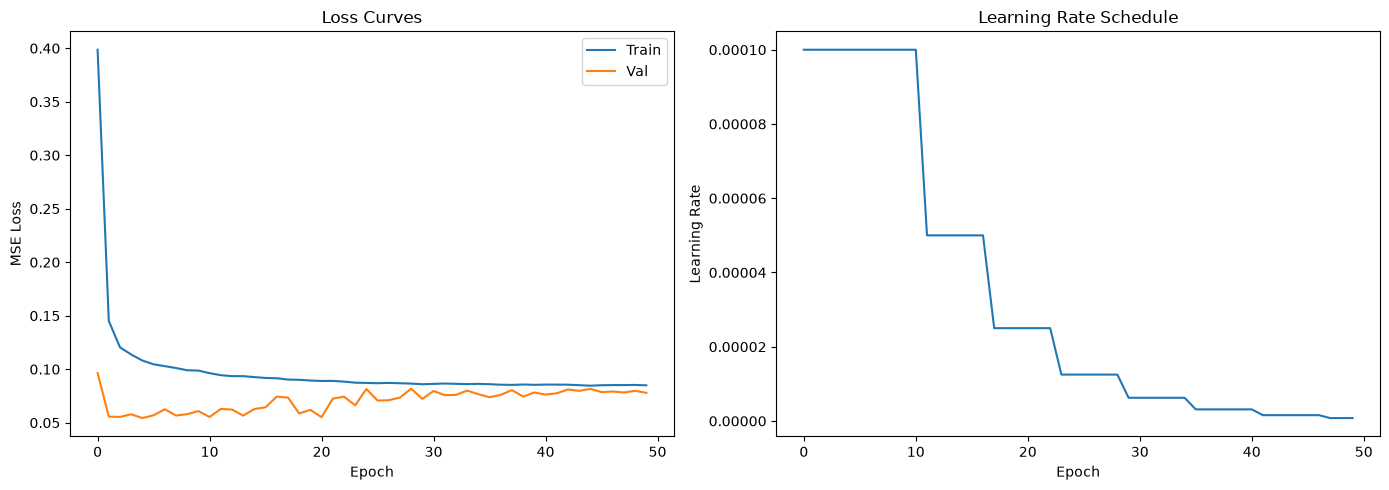

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Loss Curves")
ax1.legend()

ax2.plot(history["lr"])
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule")

plt.tight_layout()
plt.show()

## 9. Evaluate on Test Set

In [13]:
y_pred = trainer.predict(test_loader)
print(f"Predictions shape: {y_pred.shape}")
print(f"Test MSE: {np.mean((y_pred - y_test) ** 2):.6f}")
print(f"Test MAE: {np.mean(np.abs(y_pred - y_test)):.6f}")

Predictions shape: (3332, 24)
Test MSE: 0.070336
Test MAE: 0.200235
